In [ ]:
# =======================
# CONFIG
# =======================
DATA_PATH = "Fragrance Dataset - COM7022 - [4037].csv"

NOTE_COL_KEYWORDS = ["top","head","heart","middle","base","bottom","note","notes"]
NOTE_MIN_DOC_FREQ = 5
ONEHOT_CAT_MAX_UNIQUE = 15
CATEGORICAL_HINTS = ["gender","season","family","group","type","category",
                     "concentration","strength","day","night","occasion","brand"]

K_RANGE = range(2, 11)       # for KMeans/Agglomerative
DBSCAN_MIN_SAMPLES = [5, 10]
TSNE_RUN = True              # set to False to skip t-SNE (faster)
RANDOM_STATE = 42

import re, json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Import maplt for visualizations
import seaborn as sns # Import seaborn for color palettes

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7,5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))

if "brand" in df.columns:
    df["Brand_clean"] = (
        df["brand"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)   # collapse multiple spaces
        .str.replace(r"[®™]", "", regex=True)   # remove symbols if present
        .str.title()                            # Title Case: "dior" -> "Dior"
    )
    df.loc[df["brand"].isna() | (df["brand"].astype(str).str.strip() == ""), "Brand_clean"] = np.nan

# 2) Normalize Title/Name (adjust column name if different)
name_col = None
for c in df.columns:
    if c.lower() in ["title", "name", "fragrance", "perfume", "product"]:
        name_col = c
        break

if name_col:
    df["Title_clean"] = (
        df[name_col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    df.loc[df[name_col].isna() | (df[name_col].astype(str).str.strip() == ""), "Title_clean"] = np.nan

Shape: (1000, 10)


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,NaN,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


In [ ]:
print("Missing values in 'brand' column:")
print(df['brand'].isnull().sum())

print("\nMissing values in 'title' column:")
print(df['title'].isnull().sum())

Missing values in 'brand' column:
1

Missing values in 'title' column:
0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              996 non-null    float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
 10  Brand_clean        999 non-null    object 
 11  Title_clean        1000 non-null   object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


In [ ]:
missing_brand_row = df[df['brand'].isnull()]
display(missing_brand_row)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Brand_clean,Title_clean
567,NaN,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne...,Eau de Parfum,55.16,US $55.16/ea,NaN,"Limited quantity available / 3,110 sold",3110.0,"May 24, 2024 07:53:50 PDT","Hackensack, New Jersey, United States",NaN,Versace Pour Homme Oud Noir 3.4 oz EDP Cologne...


In [ ]:
df.loc[df['brand'].isnull(), 'brand'] = 'Versace'
display(df[df['brand'] == 'Versace'])

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Brand_clean,Title_clean
14,Versace,Eau Fraiche By Versace 3.4 oz 100 ml Eau de To...,Eau de Toilette,34.99,US $34.99/ea,7.0,7 available / 136 sold,136.0,"May 24, 2024 00:02:27 PDT","Warren, Michigan, United States",Versace,Eau Fraiche By Versace 3.4 oz 100 ml Eau de To...
24,Versace,Versace Eros by Gianni Versace 3.4oz EDT Colog...,Eau de Toilette,35.99,US $35.99,2.0,2 available / 43 sold,43.0,"May 24, 2024 00:13:55 PDT","Pomona, California, United States",Versace,Versace Eros by Gianni Versace 3.4oz EDT Colog...
57,Versace,Versace Pour Homme Signature by Versace 3.4 oz...,Eau de Toilette,36.88,US $36.88/ea,NaN,"Limited quantity available / 19,899 sold",19899.0,"May 24, 2024 09:36:54 PDT","Hackensack, New Jersey, United States",Versace,Versace Pour Homme Signature by Versace 3.4 oz...
67,Versace,Versace Eros by Gianni Versace 3.4 oz 100ml ED...,Eau de Toilette,35.99,US $35.99/ea,5.0,5 available / 221 sold,221.0,"May 24, 2024 00:47:14 PDT","Dayton, New Jersey, Canada",Versace,Versace Eros by Gianni Versace 3.4 oz 100ml ED...
74,Versace,Versace Man Eau Fraiche by Gianni Versace EDT ...,Eau de Toilette,8.32,US $8.32/ea,322.0,"1,322 available / 417 sold",417.0,"May 23, 2024 08:22:19 PDT","Dallas, Texas, United States",Versace,Versace Man Eau Fraiche by Gianni Versace EDT ...
111,Versace,Versace Man Fraiche EDT Spray 3.4 oz / 100 ml ...,Eau de Toilette,30.00,US $30.00/ea,2.0,2 available / 270 sold,270.0,"May 24, 2024 01:40:45 PDT","Carlsbad, California, United States",Versace,Versace Man Fraiche EDT Spray 3.4 oz / 100 ml ...
184,Versace,Versace Eros by Gianni Versace 3.4 oz EDT Colo...,Eau de Toilette,39.77,US $39.77/ea,NaN,"Limited quantity available / 31,718 sold",31718.0,"May 24, 2024 10:26:59 PDT","Hackensack, New Jersey, United States",Versace,Versace Eros by Gianni Versace 3.4 oz EDT Colo...
188,Versace,Versace Pour Homme Signature by Versace 3.4 oz...,Eau de Toilette,44.94,US $44.94/ea,10.0,"More than 10 available / 21,310 sold",21310.0,"May 23, 2024 19:44:36 PDT","Hackensack, New Jersey, United States",Versace,Versace Pour Homme Signature by Versace 3.4 oz...
224,Versace,mini cologne Versace Pour Homme for Men Brand ...,Eau de Toilette,8.84,US $8.84/ea,10.0,"More than 10 available / 9,410 sold",9410.0,"May 23, 2024 09:06:49 PDT","Hackensack, New Jersey, United States",Versace,mini cologne Versace Pour Homme for Men Brand ...
245,Versace,Versace Pour Homme by Versace EDT for Men 3.4 ...,Eau de Toilette,37.99,US $37.99,10.0,More than 10 available / 26 sold,26.0,"Mar 01, 2024 11:28:05 PST","Miami, Florida, United States",Versace,Versace Pour Homme by Versace EDT for Men 3.4 ...


In [ ]:
print("Missing values in 'brand' column:")
print(df['brand'].isnull().sum())

Missing values in 'brand' column:
0


In [ ]:
print(df['price'].isnull().sum())

4


In [ ]:
df['type'].head()

,type
0,Eau de Parfum
1,Eau de Parfum
2,Eau de Toilette
3,Eau de Toilette
4,Fragrances


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
brand                  0
title                  0
type                   3
price                  4
priceWithCurrency      0
available            111
availableText          3
sold                   6
lastUpdated           53
itemLocation           0
Brand_clean            1
Title_clean            0
dtype: int64


In [ ]:
!pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.6 MB/s eta 0:00:00


In [ ]:
from fuzzywuzzy import process

def standardize_brand(brand, brand_list, threshold=80):
    if pd.isna(brand):
        return np.nan
    # Find the best match in the predefined brand list
    match, score = process.extractOne(brand, brand_list)
    if score >= threshold:
        return match
    else:
        return brand # Return original if no good match found

# Get a list of unique brands from the cleaned brand column
unique_brands = df['Brand_clean'].dropna().unique().tolist()

# Apply standardization to the original 'brand' column
df['brand_standardized'] = df['brand'].apply(lambda x: standardize_brand(x, unique_brands))

# Display the original and standardized brand columns for comparison
display(df[['brand', 'Brand_clean', 'brand_standardized']].head(20))

,brand,Brand_clean,brand_standardized
0,Dior,Dior,Dior
1,AS SHOW,As Show,As Show
2,Unbranded,Unbranded,Unbranded
3,Giorgio Armani,Giorgio Armani,Giorgio Armani
4,Lattafa,Lattafa,Lattafa
5,Multiple Brands,Multiple Brands,Multiple Brands
6,Maison Alhambra,Maison Alhambra,Maison Alhambra
7,Unbranded,Unbranded,Unbranded
8,Unbranded,Unbranded,Unbranded
9,Gucci,Gucci,Gucci


In [ ]:
display(df['brand_standardized'].head(20))

,brand_standardized
0,Dior
1,As Show
2,Unbranded
3,Giorgio Armani
4,Lattafa
5,Multiple Brands
6,Maison Alhambra
7,Unbranded
8,Unbranded
9,Gucci


In [ ]:
#Fixing the Type Column
has_slash = df["type"].astype(str).str.contains("/")

# How many rows?
print("Rows with '/' in type:", has_slash.sum())

# (Optional) see unique problematic values
print(df.loc[has_slash, "type"].unique())



Rows with '/' in type: 4
['/' 'Eau de Parfum/ Eau de Toilette']


In [ ]:
df.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Brand_clean,Title_clean,brand_standardized
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Dior
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",As Show,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,As Show
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",Unbranded,HOGO BOSS cologne For Men 3.4 oz,Unbranded
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,NaN,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Giorgio Armani
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Lattafa


In [ ]:
df['type'].isnull().sum()

np.int64(3)

In [ ]:
def clean_type(raw_type, title):
    s = (str(raw_type) + " " + str(title)).lower()
    if "eau de parfum" in s or " edp" in s or "parfum" in s:
        return "Eau de Parfum"
    if "eau de toilette" in s or " edt" in s:
        return "Eau de Toilette"
    if "eau de cologne" in s or " edc" in s or "cologne" in s:
        return "Eau de Cologne"
    if "body mist" in s or "body spray" in s or " mist" in s:
        return "Body Mist / Spray"
    if "deodorant" in s or " deo" in s:
        return "Deodorant"
    if "after shave" in s or "aftershave" in s:
        return "After Shave"
    if "hair mist" in s:
        return "Hair Mist"
    if "set" in s or "coffret" in s or "gift" in s:
        return "Gift Set / Coffret"
    return "Other / Unknown"

df["type_clean"] = df.apply(lambda r: clean_type(r["type"], r["title"]), axis=1)

# 2) Replace '/' with mapped value
df.loc[df["type"].astype(str).str.strip() == "/", "type"] = df["type_clean"]

# 3) List unique final types
for t in sorted(df["type"].dropna().unique()):
    print("-", t)

- Aftershave
- Assorted
- Body Oil
- Body Spray
- Car Air Freshener
- Cologne
- Cologne spray
- Concentrated Uncut Pure Body Oil
- DIOR HOMME COLOGNE
- De Nuit
- Deodorant
- Deodorant Body Spray
- Does not apply
- EAU DE COLOGNE SPRAY
- EDC
- EDT
- EXTRAIT DE PARFUM
- Eau De Cologne
- Eau De Parfum
- Eau De Parfum Intense
- Eau De Toilette
- Eau De Toilette, Eau De Parfum, Eau De Parfum Intense
- Eau de Cologne
- Eau de Cologne Spray, Cologne Spray
- Eau de Parfum
- Eau de Parfum Intense
- Eau de Parfum/ Eau de Toilette
- Eau de Perfume
- Eau de Toilette
- Eau de Toilette Intense
- Eau de Toilette, Cologne Spray
- Eau de Toillette
- Eau de toilette
- Editions Parfums
- Elixir
- Elixir de Parfum
- Extrait De Parfum
- Extrait de Parfum
- Fine Cologne
- Fragrance & Perfume
- Fragrance Body Spray
- Fragrance Oil
- Fragrance Rolling Ball
- Fragrances
- Gift Sets
- Jo Malone Cologne Intense Spray
- LE PARFUM
- Oil
- PARFUM
- Parfum
- Parfum Intense
- Perfume
- Pheromone
- Roll On
- Splash-on

In [ ]:
#Reducing type column to 10 types for modelling easier!
#Parfum / Extrait / Elixir

#Eau de Parfum

#Eau de Toilette

#Eau de Cologne / Cologne

#Body Spray / Mist

#Perfume Oil / Roll-On

#Deodorant

#Aftershave

#Gift / Set / Assorted

#Other / Misc


df["type"] = df["type"].astype(str).str.strip()

type_map = {
    # Aftershave
    "Aftershave": "Aftershave",

    # Body / Perfume Oils
    "Body Oil": "Body / Perfume Oil",
    "Concentrated Uncut Pure Body Oil": "Body / Perfume Oil",
    "Oil": "Body / Perfume Oil",
    "Fragrance Oil": "Body / Perfume Oil",

    # Body / Fragrance Sprays & similar
    "Body Spray": "Body Spray / Mist",
    "Fragrance Body Spray": "Body Spray / Mist",
    "Deodorant Body Spray": "Body Spray / Mist",
    "Car Air Freshener": "Body Spray / Mist",

    # Cologne & EDC
    "Cologne": "Eau de Cologne / Cologne",
    "cologne": "Eau de Cologne / Cologne",
    "Cologne spray": "Eau de Cologne / Cologne",
    "Fine Cologne": "Eau de Cologne / Cologne",
    "EAU DE COLOGNE SPRAY": "Eau de Cologne / Cologne",
    "Eau De Cologne": "Eau de Cologne / Cologne",
    "Eau de Cologne": "Eau de Cologne / Cologne",
    "Eau de Cologne Spray, Cologne Spray": "Eau de Cologne / Cologne",
    "EDC": "Eau de Cologne / Cologne",
    "DIOR HOMME COLOGNE": "Eau de Cologne / Cologne",
    "Jo Malone Cologne Intense Spray": "Eau de Cologne / Cologne",

    # Eau de Toilette (EDT)
    "EDT": "Eau de Toilette",
    "edt": "Eau de Toilette",
    "Eau De Toilette": "Eau de Toilette",
    "Eau de Toilette": "Eau de Toilette",
    "Eau de toilette": "Eau de Toilette",
    "Eau de Toillette": "Eau de Toilette",
    "Eau de Toilette Intense": "Eau de Toilette",
    "Eau de Toilette, Cologne Spray": "Eau de Toilette",

    # Eau de Parfum (EDP)
    "Eau De Parfum": "Eau de Parfum",
    "Eau de Parfum": "Eau de Parfum",
    "Eau De Parfum Intense": "Eau de Parfum",
    "Eau de Parfum Intense": "Eau de Parfum",
    "Eau de Perfume": "Eau de Parfum",
    "~ THE ONE EAU DE PARFUM SPRAY ~": "Eau de Parfum",

    # Parfum / Extrait / Elixir
    "EXTRAIT DE PARFUM": "Parfum / Extrait",
    "Extrait De Parfum": "Parfum / Extrait",
    "Extrait de Parfum": "Parfum / Extrait",
    "Elixir": "Parfum / Extrait",
    "Elixir de Parfum": "Parfum / Extrait",
    "LE PARFUM": "Parfum / Extrait",
    "le parfum": "Parfum / Extrait",
    "PARFUM": "Parfum / Extrait",
    "Parfum": "Parfum / Extrait",
    "Parfum Intense": "Parfum / Extrait",
    "Perfume": "Parfum / Extrait",
    "Editions Parfums": "Parfum / Extrait",
    "Fragrance & Perfume": "Parfum / Extrait",

    # Roll-on / Splash formats
    "Roll On": "Roll-on / Splash",
    "Fragrance Rolling Ball": "Roll-on / Splash",
    "Splash-on": "Roll-on / Splash",

    # Deodorant
    "Deodorant": "Deodorant",

    # Gift / Mixed / Other (explicit from your list)
    "Gift Sets": "Gift / Mixed / Other",
    "Assorted": "Gift / Mixed / Other",
    "Various": "Gift / Mixed / Other",
    "Fragrances": "Gift / Mixed / Other",
    "Does not apply": "Gift / Mixed / Other",
    "Pheromone": "Gift / Mixed / Other",
    "Unscented": "Gift / Mixed / Other",
    "De Nuit": "Gift / Mixed / Other",
    "Y": "Gift / Mixed / Other",
    "Eau de Parfum/ Eau de Toilette": "Gift / Mixed / Other",
    "Eau De Toilette, Eau De Parfum, Eau De Parfum Intense": "Gift / Mixed / Other",
}

# Apply mapping; anything not explicitly mapped goes to "Gift / Mixed / Other"
df["type"] = df["type"].map(type_map).fillna("Gift / Mixed / Other")

# Check final condensed types
print(sorted(df["type"].unique()))

['Aftershave', 'Body / Perfume Oil', 'Body Spray / Mist', 'Deodorant', 'Eau de Cologne / Cologne', 'Eau de Parfum', 'Eau de Toilette', 'Gift / Mixed / Other', 'Parfum / Extrait', 'Roll-on / Splash']


In [ ]:
print("Unique values in 'type' column:")
for t in sorted(df['type'].dropna().unique()):
    print("-", t)

Unique values in 'type' column:
- Aftershave
- Body / Perfume Oil
- Body Spray / Mist
- Deodorant
- Eau de Cologne / Cologne
- Eau de Parfum
- Eau de Toilette
- Gift / Mixed / Other
- Parfum / Extrait
- Roll-on / Splash


In [ ]:
df.head(1000)

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Brand_clean,Title_clean,brand_standardized,type_clean
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Dior,Eau de Parfum
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",As Show,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,As Show,Eau de Parfum
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",Unbranded,HOGO BOSS cologne For Men 3.4 oz,Unbranded,Eau de Toilette
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,NaN,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Giorgio Armani,Eau de Toilette
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Gift / Mixed / Other,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Lattafa,Eau de Parfum
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States",Guess,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Guess,Eau de Toilette
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Armaf,Eau de Toilette
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States",Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Paco Rabanne,Eau de Toilette
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States",Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Lomani,Eau de Toilette


In [ ]:
display(df['brand'].head(20))

,brand
0,Dior
1,AS SHOW
2,Unbranded
3,Giorgio Armani
4,Lattafa
5,Multiple Brands
6,Maison Alhambra
7,Unbranded
8,Unbranded
9,Gucci


In [ ]:

display(df.head())

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Brand_clean,Title_clean,brand_standardized,type_clean
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Dior,Eau de Parfum
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",As Show,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,As Show,Eau de Parfum
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",Unbranded,HOGO BOSS cologne For Men 3.4 oz,Unbranded,Eau de Toilette
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,NaN,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Giorgio Armani,Eau de Toilette
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Gift / Mixed / Other,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Lattafa,Eau de Parfum


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
brand                   0
title                   0
type                    0
price                   4
priceWithCurrency       0
available             111
availableText           3
sold                    6
lastUpdated            53
itemLocation            0
Brand_clean             1
Title_clean             0
brand_standardized      0
type_clean              0
dtype: int64


In [ ]:
display(df[df['price'].isnull()])

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Brand_clean,Title_clean,brand_standardized,type_clean
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,NaN,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Giorgio Armani,Eau de Toilette
10,Ralph Lauren,Polo Blue by Ralph Lauren 4.2 oz EDT Cologne f...,Eau de Toilette,NaN,US $34.99/ea,10.0,More than 10 available / 615 sold,615.0,"May 24, 2024 07:53:23 PDT","Ecorse, Michigan, United States",Ralph Lauren,Polo Blue by Ralph Lauren 4.2 oz EDT Cologne f...,Ralph Lauren,Eau de Toilette
13,As Show,Sauvage Eau de Parfum Spray For Men 3.4 Oz/100...,Eau de Parfum,NaN,US $59.99/ea,9.0,9 available / 63 sold,63.0,"May 23, 2024 03:08:18 PDT","Dayton,New Jersey, Hong Kong",As Show,Sauvage Eau de Parfum Spray For Men 3.4 Oz/100...,As Show,Eau de Parfum
20,Dolce & Gabbana,Light Blue by Dolce & Gabbana 4.2 oz Cologne f...,Eau de Toilette,NaN,US $29.94/ea,NaN,"Limited quantity available / 9,208 sold",9208.0,"May 23, 2024 20:04:11 PDT","Hackensack, New Jersey, United States",Dolce & Gabbana,Light Blue by Dolce & Gabbana 4.2 oz Cologne f...,Dolce & Gabbana,Eau de Toilette


In [ ]:
# Fill missing 'price' values using 'priceWithCurrency'
def extract_price_from_currency(row):
    if pd.isnull(row['price']) and pd.notnull(row['priceWithCurrency']):
        match = re.search(r'[\d.]+', row['priceWithCurrency'])
        if match:
            return float(match.group(0))
    return row['price']

df['price'] = df.apply(extract_price_from_currency, axis=1)

print("Missing values in 'price' column after filling:")
print(df['price'].isnull().sum())

Missing values in 'price' column after filling:
0


In [ ]:
missing_brand_indices = df[df['brand'].isnull()].index
if not missing_brand_indices.empty:
    display(df.iloc[missing_brand_indices])
else:
    print("No missing values found in the 'brand' column.")

No missing values found in the 'brand' column.


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
brand                   0
title                   0
type                    0
price                   0
priceWithCurrency       0
available             111
availableText           3
sold                    6
lastUpdated            53
itemLocation            0
Brand_clean             1
Title_clean             0
brand_standardized      0
type_clean              0
dtype: int64


In [ ]:
print(df[df['price'].isnull()])

Empty DataFrame
Columns: [brand, title, type, price, priceWithCurrency, available, availableText, sold, lastUpdated, itemLocation, Brand_clean, Title_clean, brand_standardized, type_clean]
Index: []


In [ ]:
#Dealing with the missing types, mapping and merging them together.

# Work only on genuinely missing/blank types
missing_type = df["type"].isna() | (df["type"].astype(str).str.strip() == "")

# 1) If title contains "cologne" -> set type = "Eau de Cologne"
mask_cologne = missing_type & df["title"].str.contains("cologne", case=False, na=False)
df.loc[mask_cologne, "type"] = "Eau de Cologne"

# 2) If title contains "edp" or "eau de parfum" -> set type = "Eau de Parfum"
mask_edp = missing_type & df["title"].str.contains(r"edp|eau de parfum", case=False, na=False)
df.loc[mask_edp, "type"] = "Eau de Parfum"


In [ ]:
df.isnull().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,111
availableText,3
sold,6
lastUpdated,53
itemLocation,0


In [ ]:
# Drop columns that are no longer needed
cols_to_drop = ['Brand_clean', 'brand_standardized', 'type_clean']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

print("Dropped columns:", [col for col in cols_to_drop if col not in df.columns])
display(df.head())

Dropped columns: ['Brand_clean', 'brand_standardized', 'type_clean']


,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Title_clean
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States",Christian Dior Sauvage Men's EDP 3.4 oz Fragra...
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada",A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States",HOGO BOSS cologne For Men 3.4 oz
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States",Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Gift / Mixed / Other,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States",Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...


In [ ]:
df.isnull().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,111
availableText,3
sold,6
lastUpdated,53
itemLocation,0


In [ ]:
#Fixing Price Column
pwc = [c for c in df.columns if c.lower() == "pricewithcurrency"][0]

df["Price"] = pd.to_numeric(df.get("Price"), errors="coerce")

tmp = df[pwc].astype(str).str.extract(r'([\d.,]+)', expand=False)
tmp = tmp.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
df["Price"] = df["Price"].fillna(tmp.astype(float))

print("Missing Price:", df["Price"].isna().sum())

Missing Price: 0


In [ ]:
df['Price'].isna().sum()

np.int64(0)

In [ ]:
df = df[~df["availableText"].isna()]

In [ ]:
df['available'
].isna().sum()

np.int64(108)

In [ ]:
# Identify rows where "available" is missing and "availableText" contains relevant information
# The masks are defined below within the fill_available function logic

# The following lines were causing issues and are redundant with the fill_available function logic
# mask = df["availableText"].str.contains("Limited quantity", case=False, na=False) & df["available"].isna()
# mask_one = df["availableText"].str.contains("Last One", case=False, na=False) & df["available"].isna()
# df.loc[mask, "available"] = df.groupby("type")["available"].transform("mean")
# df.loc[mask_one, "available"] = df["av.ailable"].fillna # Typo and incomplete method call


# 1) Limited quantity -> fill with mean(available) per type (only where available is NaN)
mask_limited = df["availableText"].str.contains("Limited quantity", case=False, na=False) & df["available"].isna()
if mask_limited.any():
    df.loc[mask_limited, "available"] = df.groupby("type")["available"].transform(lambda x: x.mean() if not x.isnull().all() else np.nan)


# 2) Last One -> set available = 1 (only where available is NaN)
mask_last_one = df["availableText"].str.contains("Last One", case=False, na=False) & df["available"].isna()
df.loc[mask_last_one, "available"] = 1

# 3) More than 10 available -> set available = 10 (only where available is NaN)
mask_more_than = df["availableText"].str.contains("More than 10 available", case=False, na=False) & df["available"].isna()
df.loc[mask_more_than, "available"] = 10

def lots_items_qty(text):
    # "More than 10 lots available (3 items per lot)" -> 10 * 3 = 30
    if not isinstance(text, str):
        return np.nan
    m = re.search(r"More than\s*(\d+)\s*lots?.*?\((\d+)\s+items?\s*per\s*lot\)", text, flags=re.I)
    return int(m.group(1)) * int(m.group(2)) if m else np.nan

# Apply the lots_items_qty function to fill missing 'available' values based on the pattern
mask_lots = df["available"].isna()
df.loc[mask_lots, "available"] = df.loc[mask_lots, "availableText"].apply(lots_items_qty)

# Final check for remaining missing values in "available"
print("Missing values in 'available' after processing availableText:")
print(df["available"].isnull().sum())

Missing values in 'available' after processing availableText:
0


In [ ]:
df['available'
].isnull().sum()

np.int64(0)

In [ ]:
display(df[df['available'].isnull()])

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Title_clean,Price


In [ ]:
missing_available_indices = df[df['available'].isnull()].index
if not missing_available_indices.empty:
    display(df.loc[missing_available_indices])
else:
    print("No missing values found in the 'available' column.")

No missing values found in the 'available' column.


In [ ]:
display(df[df['sold'].isnull()])

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,Title_clean,Price
152,Dossier,Dossier Aromatic Pineapple Eau de Parfum. Size...,Eau de Parfum,20.00,US $20.00/ea,10.0,More than 10 available,NaN,NaN,"Los Angeles, California, United States",Dossier Aromatic Pineapple Eau de Parfum. Size...,2000.0
792,Bath & Body Works,Bath & Body Works Men's Collection FRESHWATER ...,Eau de Cologne / Cologne,29.97,US $29.97,4.0,4 available,NaN,NaN,"Dover, Delaware, United States",Bath & Body Works Men's Collection FRESHWATER ...,2997.0
797,Tom Ford,"5 Original M&H Tom Ford Impressions, Tobacco V...",Body / Perfume Oil,29.99,US $29.99/ea,10.0,10 available,NaN,NaN,"St. George, Utah, United States","5 Original M&H Tom Ford Impressions, Tobacco V...",2999.0


In [ ]:
# Fill missing 'sold' values with the mean 'sold' for each 'brand'
df['sold'] = df['sold'].fillna(df.groupby('brand')['sold'].transform('mean'))

print("Missing values in 'sold' column after filling:")
print(df['sold'].isnull().sum())

Missing values in 'sold' column after filling:
0


In [ ]:
if 'lastUpdated' in df.columns:
    df = df.drop(columns=['lastUpdated'])
    print("Dropped column: lastUpdated")
else:
    print("Column 'lastUpdated' not found in DataFrame.")

display(df.head())

Dropped column: lastUpdated


,brand,title,type,price,priceWithCurrency,available,availableText,sold,itemLocation,Title_clean,Price
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.000000,More than 10 available / 116 sold,116.0,"Allen Park, Michigan, United States",Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,8499.0
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.000000,8 available / 48 sold,48.0,"Atlanta, Georgia, Canada",A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,10999.0
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.000000,More than 10 available / 27 sold,27.0,"Dearborn, Michigan, United States",HOGO BOSS cologne For Men 3.4 oz,10000.0
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.000000,2 available / 159 sold,159.0,"Reinholds, Pennsylvania, United States",Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,4499.0
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Gift / Mixed / Other,16.91,US $16.91,4.914894,Limited quantity available / 156 sold,156.0,"Brooklyn, New York, United States",Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,1691.0


In [ ]:
if 'Title_clean' in df.columns:
    df = df.drop(columns=['Title_clean'])
    print("Dropped column: Title_clean")
else:
    print("Column 'Title_clean' not found in DataFrame.")

display(df.head())

Dropped column: Title_clean


,brand,title,type,price,priceWithCurrency,available,availableText,sold,itemLocation,Price
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.000000,More than 10 available / 116 sold,116.0,"Allen Park, Michigan, United States",8499.0
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.000000,8 available / 48 sold,48.0,"Atlanta, Georgia, Canada",10999.0
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.000000,More than 10 available / 27 sold,27.0,"Dearborn, Michigan, United States",10000.0
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.000000,2 available / 159 sold,159.0,"Reinholds, Pennsylvania, United States",4499.0
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Gift / Mixed / Other,16.91,US $16.91,4.914894,Limited quantity available / 156 sold,156.0,"Brooklyn, New York, United States",1691.0


In [ ]:
missing_available_indices = df[df['available'].isnull()].index
if not missing_available_indices.empty:
    display(df.iloc[missing_available_indices])
else:
    print("No missing values found in the 'available' column.")

No missing values found in the 'available' column.


In [ ]:
df.isna().sum()

,0
brand,0
title,0
type,0
price,0
priceWithCurrency,0
available,0
availableText,0
sold,0
itemLocation,0
Price,0


In [ ]:
import pandas as pd
import re
from difflib import SequenceMatcher

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score

# =========================================
# 0. CONFIG
# =========================================
INPUT_PATH = "Fragrance Dataset - COM7022 - [4037].csv"
OUTPUT_PATH = "Fragrance_with_fuzzy_ml_final.xlsx"

FUZZY_THRESHOLD = 0.65       # for brand string similarity
MIN_SAMPLES_PER_BRAND = 6      # drop ultra-rare brands from training (Increased to 6)
ML_CONF_THRESHOLD = 0.65       # when to trust ML over fuzzy

# =========================================
# 1. LOAD & BASIC CLEANING
# =========================================
df = pd.read_csv(INPUT_PATH)

# keep rows with title & brand
df = df.dropna(subset=['title', 'brand']).copy()

def clean_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9 ]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

df["title_clean"] = df["title"].apply(clean_text)
df["brand_clean"] = df["brand"].apply(clean_text)

# =========================================
# 2. FUZZY BRAND NORMALIZATION (70%+)
# =========================================

brand_counts = df["brand_clean"].value_counts()
canonical_brands = list(brand_counts.index)

def best_fuzzy_match(query: str, candidates, threshold: float = FUZZY_THRESHOLD) -> str:
    query = query.strip()
    if not query:
        return query

    best = query
    best_score = 0.0

    for c in candidates:
        if c == query:
            return c  # exact match ideal
        score = SequenceMatcher(None, query, c).ratio()
        if score > best_score:
            best_score = score
            best = c

    return best if best_score >= threshold else query

df["brand_fuzzy"] = df["brand_clean"].apply(
    lambda b: best_fuzzy_match(b, canonical_brands, FUZZY_THRESHOLD)
)

# labels we consider junk / non-informative
noise_labels_raw = [
    "unbranded", "assorted", "as show", "does not apply",
    "no brand", "none", "n a", ""
]
noise_labels = {clean_text(x) for x in noise_labels_raw}
brand_set = set(canonical_brands)

def refine_with_title(row):
    """
    If fuzzy label is noise, try to detect a known brand in title.
    Choose the longest matching brand substring.
    """
    b = row["brand_fuzzy"]
    title = row["title_clean"]

    if b in noise_labels:
        hits = [cb for cb in brand_set if cb and cb in title]
        if hits:
            return max(hits, key=len)
    return b

df["brand_fuzzy"] = df.apply(refine_with_title, axis=1)

# =========================================
# 3. BUILD TRAINING DATA (CLEAN TARGET)
# =========================================

# drop rows still junk after refinement
df_train = df[~df["brand_fuzzy"].isin(noise_labels)].copy()

# keep only brands with enough samples
brand_freq = df_train["brand_fuzzy"].value_counts()
valid_brands = set(brand_freq[brand_freq >= MIN_SAMPLES_PER_BRAND].index)
df_train = df_train[df_train["brand_fuzzy"].isin(valid_brands)].copy()

print(f"Training rows: {len(df_train)}")
print(f"Distinct brands (train): {df_train['brand_fuzzy'].nunique()}")

X_text = df_train["title_clean"]
y = df_train["brand_fuzzy"]

# =========================================
# 4. TRAIN / TEST SPLIT + VECTORIZER
# =========================================
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    stratify=y, # Added stratify back
    random_state=42
)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2
)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

# =========================================
# 5. MODEL: LinearSVC + CALIBRATION
# =========================================
# LinearSVC is strong on sparse text; CalibratedClassifierCV adds predict_proba.
base_svm = LinearSVC()
clf = CalibratedClassifierCV(estimator=base_svm, method='sigmoid', cv=5)
clf.fit(X_train, y_train)

# =========================================
# 6. EVALUATION (HOLD-OUT TEST)
# =========================================
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy (fuzzy + LinearSVC + calibrated): {acc:.4f}")
print(f"Macro F1 (fuzzy + LinearSVC + calibrated): {macro_f1:.4f}")

# =========================================
# 7. PREDICT FOR ALL ROWS
# =========================================
X_all = vectorizer.transform(df["title_clean"])
proba_all = clf.predict_proba(X_all)
labels = clf.classes_

pred_indices = proba_all.argmax(axis=1)
df["brand_ml_pred"] = [labels[i] for i in pred_indices]
df["brand_ml_conf"] = proba_all.max(axis=1)

# =========================================
# 8. COMBINE: FINAL BRAND DECISION
# =========================================
def choose_final_brand(row):
    fuzzy = row["brand_fuzzy"]
    ml = row["brand_ml_pred"]
    conf = row["brand_ml_conf"]

    # Case 1: good fuzzy label (not junk, frequent) -> start from that
    fuzzy_ok = (fuzzy not in noise_labels) and (fuzzy in valid_brands)

    if fuzzy_ok:
        # If ML is very confident AND disagrees -> allow override
        if (ml != fuzzy) and (conf >= ML_CONF_THRESHOLD):
            return ml
        else:
            return fuzzy
    else:
        # Fuzzy is junk/unknown: trust ML if confident, else keep fuzzy
        if conf >= ML_CONF_THRESHOLD:
            return ml
        else:
            return fuzzy

df["brand_final"] = df.apply(choose_final_brand, axis=1)

# =========================================
# 9. SAVE RESULT
# =========================================
df.to_excel(OUTPUT_PATH, index=False)
print(f"Saved final dataset to: {OUTPUT_PATH}")

Training rows: 662
Distinct brands (train): 41
Accuracy (fuzzy + LinearSVC + calibrated): 0.8872
Macro F1 (fuzzy + LinearSVC + calibrated): 0.8784
Saved final dataset to: Fragrance_with_fuzzy_ml_final.xlsx


In [ ]:
import numpy as np
import pandas as pd
import re

from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.impute import SimpleImputer

# ---------- 1.1 Detect note columns ----------
NOTE_COL_KEYS = ["top", "heart", "middle", "base", "note", "notes", "accord"]

def is_note_col(col):
    c = col.lower()
    return any(k in c for k in NOTE_COL_KEYS)

note_cols = [c for c in df.columns if is_note_col(c)]
print("Note columns:", note_cols)

# ---------- 1.2 Tokenize notes per perfume ----------
splitter = re.compile(r'[;,/|+&]')

def row_tokens(row):
    toks = []
    for c in note_cols:
        v = row.get(c, np.nan)
        if pd.isna(v):
            continue
        parts = splitter.split(str(v))
        toks.extend([p.strip().lower() for p in parts if p.strip()])
    return list(set(toks))  # unique notes per perfume

note_lists = df.apply(row_tokens, axis=1)

# ---------- 1.3 Multi-hot encode notes ----------
mlb = MultiLabelBinarizer(sparse_output=False)
note_mat_all = mlb.fit_transform(note_lists)
note_names_all = np.array(mlb.classes_)

# keep notes that appear in at least 5 perfumes
freq = note_mat_all.sum(axis=0)
keep = freq >= 5
note_mat = note_mat_all[:, keep]
note_names = note_names_all[keep]

X_notes = pd.DataFrame(
    note_mat,
    columns=[f"note::{n}" for n in note_names],
    index=df.index
)
print("Kept note features:", X_notes.shape[1])

# ---------- 1.4 Numeric features ----------
# take existing numeric columns (after your cleaning, e.g. Price, Rating, Longevity, etc.)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# optionally drop obvious ID-like columns if you have them:
drop_like = ["id", "index"]
num_cols = [c for c in num_cols if not any(k in c.lower() for k in drop_like)]

print("Numeric feature columns:", num_cols)

X_num_raw = df[num_cols].copy()
num_imputer = SimpleImputer(strategy="median")
X_num_imp = num_imputer.fit_transform(X_num_raw)
scaler = StandardScaler()
X_num = scaler.fit_transform(X_num_imp)

# ---------- 1.5 Combine ----------
if X_num.shape[1] > 0:
    X = np.hstack([X_num, X_notes.values])
else:
    X = X_notes.values

print("Final feature matrix shape:", X.shape)


Note columns: []
Kept note features: 0
Numeric feature columns: ['price', 'available', 'sold', 'brand_ml_conf']
Final feature matrix shape: (999, 4)


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

def eval_labels(X, labels):
    labels = np.array(labels)
    # ignore DBSCAN noise for cluster count check
    unique = np.unique(labels[labels != -1])
    if len(unique) < 2:
        return np.nan, np.nan, len(np.unique(labels))
    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    return sil, dbi, len(np.unique(labels))

results = []

# ---------- 2.1 K-Means ----------
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    sil, dbi, ncl = eval_labels(X, labels)
    results.append({
        "model": "KMeans",
        "params": f"k={k}",
        "n_clusters": ncl,
        "silhouette": sil,
        "dbi": dbi,
        "labels": labels
    })

# ---------- 2.2 Agglomerative (Ward) ----------
for k in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X)
    sil, dbi, ncl = eval_labels(X, labels)
    results.append({
        "model": "Agglomerative",
        "params": f"k={k}",
        "n_clusters": ncl,
        "silhouette": sil,
        "dbi": dbi,
        "labels": labels
    })

# ---------- 2.3 DBSCAN ----------
# heuristic eps from 10-NN distances
nn = NearestNeighbors(n_neighbors=10).fit(X)
distances, _ = nn.kneighbors(X)
base_eps = float(np.percentile(distances[:, -1], 90))

for eps in [base_eps*0.8, base_eps, base_eps*1.2]:
    for ms in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        sil, dbi, ncl = eval_labels(X, labels)
        results.append({
            "model": "DBSCAN",
            "params": f"eps={eps:.3f},min_samples={ms}",
            "n_clusters": ncl,
            "silhouette": sil,
            "dbi": dbi,
            "labels": labels
        })

metrics_df = pd.DataFrame([
    {k:v for k,v in r.items() if k!="labels"} for r in results
])

display(metrics_df.sort_values("silhouette", ascending=False).head(15))


,model,params,n_clusters,silhouette,dbi
3,KMeans,k=5,5,0.491219,0.680517
6,KMeans,k=8,8,0.483087,0.692921
8,KMeans,k=10,10,0.475769,0.706104
5,KMeans,k=7,7,0.473093,0.657515
2,KMeans,k=4,4,0.469420,0.721707
12,Agglomerative,k=5,5,0.467840,0.705923
14,Agglomerative,k=7,7,0.464147,0.701494
7,KMeans,k=9,9,0.463403,0.701208
1,KMeans,k=3,3,0.462150,1.111344
11,Agglomerative,k=4,4,0.460619,0.721936


In [ ]:
tmp = metrics_df.copy()
tmp["silhouette"] = tmp["silhouette"].fillna(-np.inf)

# soft preference for 3–8 clusters
def k_pref(k):
    return 0.03 if 3 <= k <= 8 else 0.0

tmp["score"] = (
    tmp["silhouette"] +
    tmp["n_clusters"].apply(k_pref) -
    0.01 * tmp["dbi"].fillna(tmp["dbi"].max())
)

best_row = tmp.sort_values("score", ascending=False).iloc[0]
best_row
# get labels for best model
best_labels = None
for r in results:
    if r["model"] == best_row["model"] and r["params"] == best_row["params"]:
        best_labels = r["labels"]
        break

df["Cluster"] = best_labels
print(best_row)
df["Cluster"].value_counts().sort_index()


model           KMeans
params             k=5
n_clusters           5
silhouette    0.491219
dbi           0.680517
score         0.514414
Name: 3, dtype: object


,count
Cluster,
0,563
1,12
2,278
3,138
4,8


In [ ]:
df.shape

(999, 17)

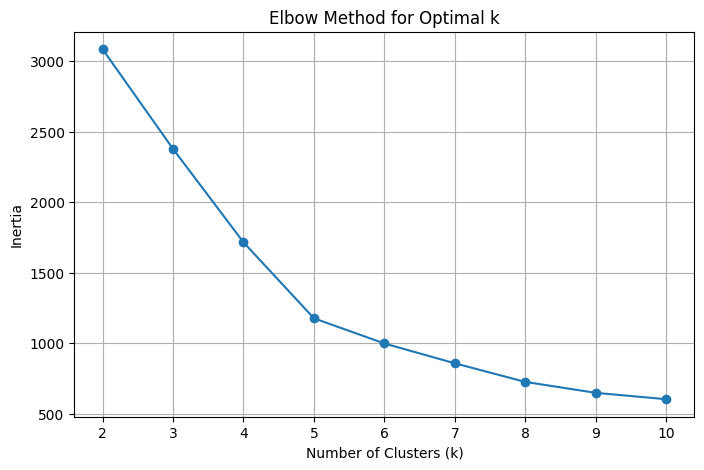

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different numbers of clusters
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

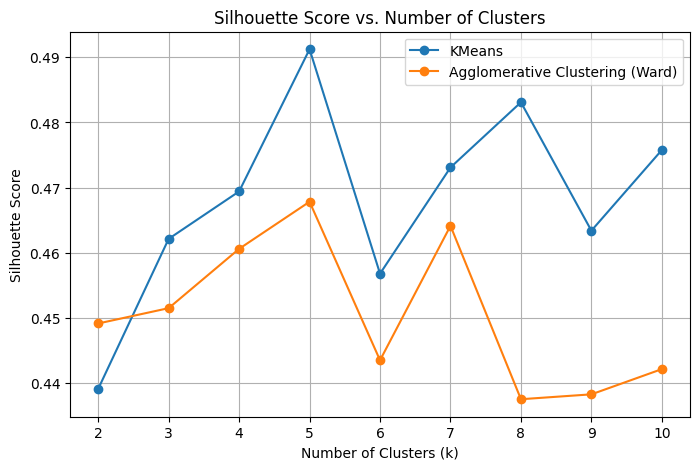

In [ ]:
plt.figure(figsize=(8, 5))

# Plot Silhouette scores for KMeans
kmeans_results = metrics_df[metrics_df['model'] == 'KMeans']
plt.plot(kmeans_results['n_clusters'], kmeans_results['silhouette'], marker='o', label='KMeans')

# Plot Silhouette scores for Agglomerative Clustering
agg_results = metrics_df[metrics_df['model'] == 'Agglomerative']
plt.plot(agg_results['n_clusters'], agg_results['silhouette'], marker='o', label='Agglomerative Clustering (Ward)')


plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.legend()
plt.show()

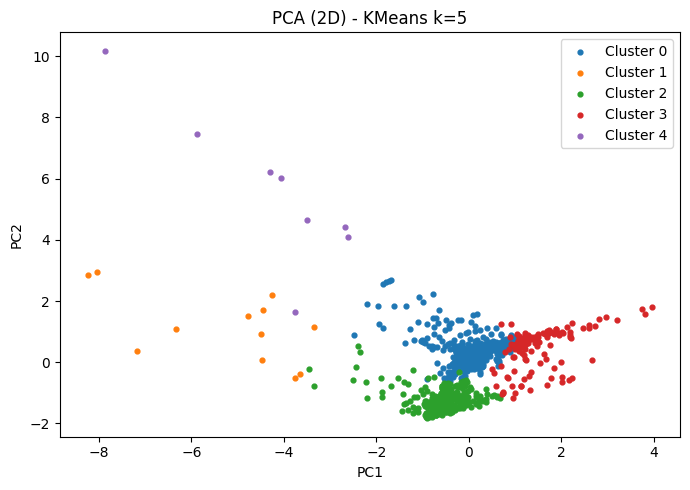

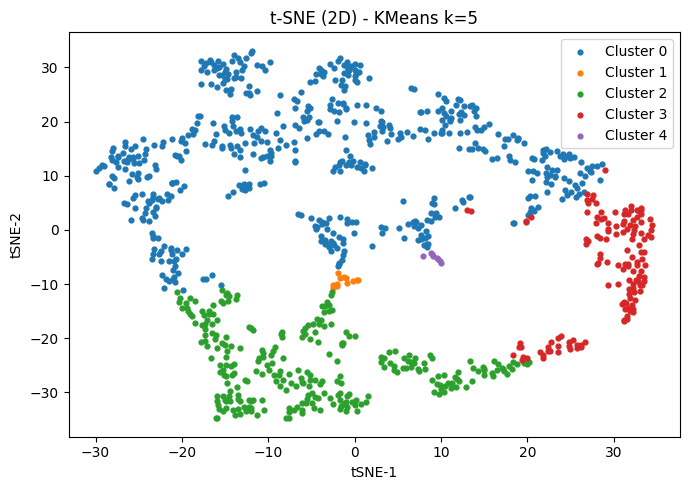

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ---------- PCA ----------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure()
for c in np.unique(best_labels):
    idx = best_labels == c
    plt.scatter(X_pca[idx,0], X_pca[idx,1], s=12, label=f"Cluster {c}")
plt.legend()
plt.title(f"PCA (2D) - {best_row['model']} {best_row['params']}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# ---------- t-SNE (optional, can be slower) ----------
tsne = TSNE(n_components=2, init="pca", learning_rate="auto",
            perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure()
for c in np.unique(best_labels):
    idx = best_labels == c
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], s=12, label=f"Cluster {c}")
plt.legend()
plt.title(f"t-SNE (2D) - {best_row['model']} {best_row['params']}")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.tight_layout()
plt.show()


In [ ]:
# note feature columns
note_cols_mh = [c for c in X_notes.columns]

cluster_profiles = []

for c in sorted(np.unique(best_labels)):
    idx = (best_labels == c)
    size = idx.sum()

    # top notes by prevalence within cluster
    means = X_notes.loc[idx, note_cols_mh].mean().sort_values(ascending=False)
    top_notes = [(n.replace("note::",""), float(v)) for n,v in means.head(10).items()]

    # numeric means for context (e.g., Price, Rating)
    num_summary = {}
    for col in num_cols:
        num_summary[col] = float(df.loc[idx, col].mean())

    # top brands if you have Brand_clean/brand_final
    top_brands = None
    for bc in ["brand_final", "Brand_clean", "Brand"]:
        if bc in df.columns:
            top_brands = df.loc[idx, bc].value_counts().head(5).to_dict()
            break

    cluster_profiles.append({
        "cluster": int(c),
        "size": int(size),
        "top_notes": top_notes,
        "numeric_means": num_summary,
        "top_brands": top_brands
    })

pd.DataFrame([{
    "cluster": p["cluster"],
    "size": p["size"],
    "top_notes": ", ".join([n for n,_ in p["top_notes"][:6]]),
    "top_brands": ", ".join((p["top_brands"] or {}).keys())
} for p in cluster_profiles])


,cluster,size,top_notes,top_brands
0,0,563,,"giorgio armani, ralph lauren, dolce gabbana, a..."
1,1,12,,"guy laroche, ralph lauren, montblanc, polo ral..."
2,2,278,,"as shown, bharara, moschino, lacoste, diesel"
3,3,138,,"giorgio armani, dior, paco rabanne, yves saint..."
4,4,8,,"versace, calvin klein, azzaro, 2nd to none, da..."


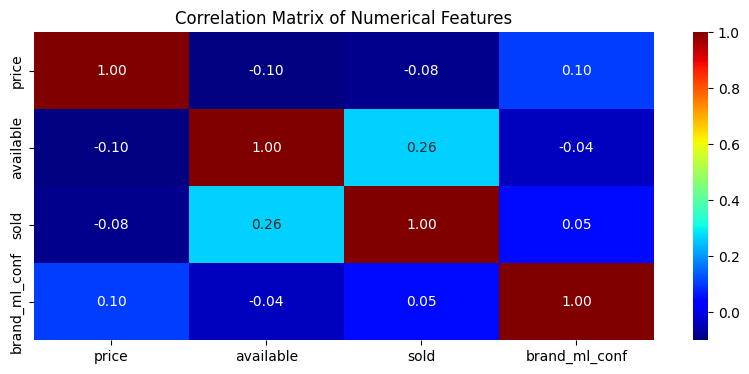

In [ ]:
#import seaborn as sns
#import matplotlib.pyplot as plt (in case of upper libraries do not work!)

# Select only the numerical columns from the original DataFrame
# (Assuming num_cols contains the names of the numerical columns used for clustering)
df_numerical = df[num_cols]

# Calculate the correlation matrix
correlation_matrix = df_numerical.corr()

# Plot the heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='jet', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

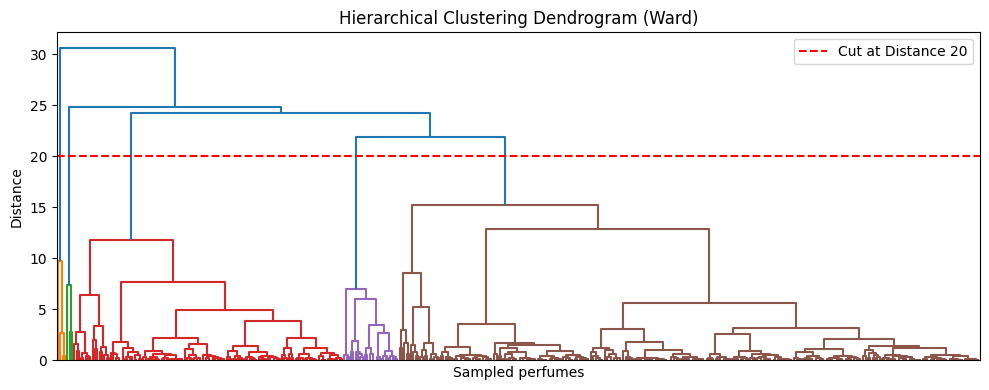

<Figure size 700x500 with 0 Axes>

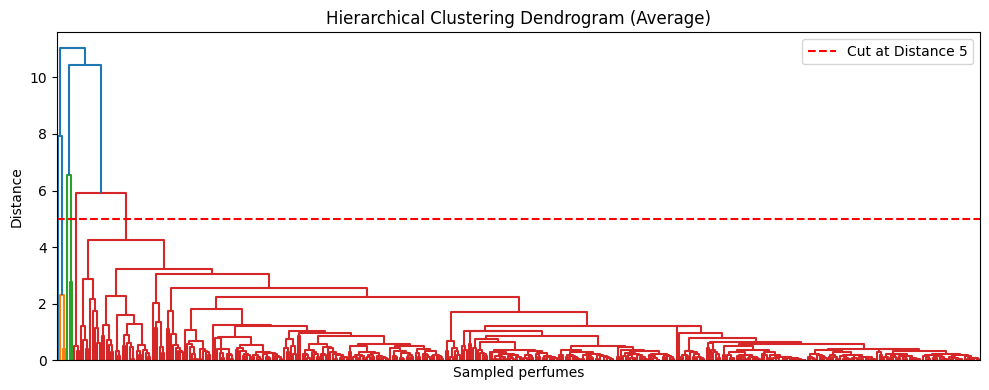

<Figure size 700x500 with 0 Axes>

In [ ]:
# Dendrogram for Hierarchical Clustering (Ward linkage, average linkage sampled for speed)
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np

# Using a subset if dataset is large
np.random.seed(42)
sample_size = min(400, X.shape[0])   # adjust if needed
idx = np.random.choice(X.shape[0], size=sample_size, replace=False)
X_sample = X[idx]

Z = linkage(X_sample, method="ward")
Z1 = linkage(X_sample, method="average")


cut_distance_ward = 20 # Example threshold for Ward linkage
cut_distance_average = 5 # Example threshold for Average linkage


plt.figure(figsize=(10, 4))
dendrogram(Z, no_labels=True, count_sort=True)
plt.axhline(y=cut_distance_ward, color='r', linestyle='--', label=f'Cut at Distance {cut_distance_ward}') # Add cutline
plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.xlabel("Sampled perfumes")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('dendrogram.png', format='png', dpi=600)

plt.figure(figsize=(10, 4))
dendrogram(Z1, no_labels=True, count_sort=True)
plt.axhline(y=cut_distance_average, color='r', linestyle='--', label=f'Cut at Distance {cut_distance_average}') # Add cutline
plt.title("Hierarchical Clustering Dendrogram (Average)")
plt.xlabel("Sampled perfumes")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig('dendrogram1.png', format='png',dpi=600)

In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X, best_labels)
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Calinski-Harabasz Score: 595.3471


In [ ]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

def eval_labels_all_metrics(X, labels):
    labels = np.array(labels)
    # Filter out noise points for metrics if DBSCAN returns -1
    valid_indices = labels != -1
    X_filtered = X[valid_indices]
    labels_filtered = labels[valid_indices]

    # Correctly assign n_unique_clusters before using it in a condition
    n_unique_clusters = len(np.unique(labels_filtered))

    if n_unique_clusters < 2:
        # Cannot compute silhouette or dbi for less than 2 clusters
        return np.nan, np.nan, np.nan, len(np.unique(labels))

    sil = silhouette_score(X_filtered, labels_filtered)
    dbi = davies_bouldin_score(X_filtered, labels_filtered)
    ch_score = calinski_harabasz_score(X_filtered, labels_filtered)
    return sil, dbi, ch_score, len(np.unique(labels))


results_ch = []

# K-Means
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    sil, dbi, ch, ncl = eval_labels_all_metrics(X, labels)
    results_ch.append({
        "model": "KMeans",
        "params": f"k={k}",
        "n_clusters": ncl,
        "silhouette": sil,
        "dbi": dbi,
        "calinski_harabasz": ch,
        "labels": labels
    })

# Agglomerative (Ward)
for k in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X)
    sil, dbi, ch, ncl = eval_labels_all_metrics(X, labels)
    results_ch.append({
        "model": "Agglomerative",
        "params": f"k={k}",
        "n_clusters": ncl,
        "silhouette": sil,
        "dbi": dbi,
        "calinski_harabasz": ch,
        "labels": labels
    })

# DBSCAN
nn = NearestNeighbors(n_neighbors=10).fit(X)
distances, _ = nn.kneighbors(X)
base_eps = float(np.percentile(distances[:, -1], 90))

for eps in [base_eps*0.8, base_eps, base_eps*1.2]:
    for ms in [5, 10]:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)
        sil, dbi, ch, ncl = eval_labels_all_metrics(X, labels)
        results_ch.append({
            "model": "DBSCAN",
            "params": f"eps={eps:.3f},min_samples={ms}",
            "n_clusters": ncl,
            "silhouette": sil,
            "dbi": dbi,
            "calinski_harabasz": ch,
            "labels": labels
        })

metrics_df_ch = pd.DataFrame([
    {k:v for k,v in r.items() if k!="labels"} for r in results_ch
])

display(metrics_df_ch.sort_values("calinski_harabasz", ascending=False).head(15))

,model,params,n_clusters,silhouette,dbi,calinski_harabasz
7,KMeans,k=9,9,0.463403,0.701208,638.792646
6,KMeans,k=8,8,0.483087,0.692921,637.722107
8,KMeans,k=10,10,0.475769,0.706104,627.910531
5,KMeans,k=7,7,0.473093,0.657515,604.816024
4,KMeans,k=6,6,0.456812,0.694011,596.422923
3,KMeans,k=5,5,0.491219,0.680517,595.347069
12,Agglomerative,k=5,5,0.467840,0.705923,558.670922
13,Agglomerative,k=6,6,0.443538,0.679940,547.960738
17,Agglomerative,k=10,10,0.442180,0.759508,540.219084
16,Agglomerative,k=9,9,0.438314,0.727211,538.284824


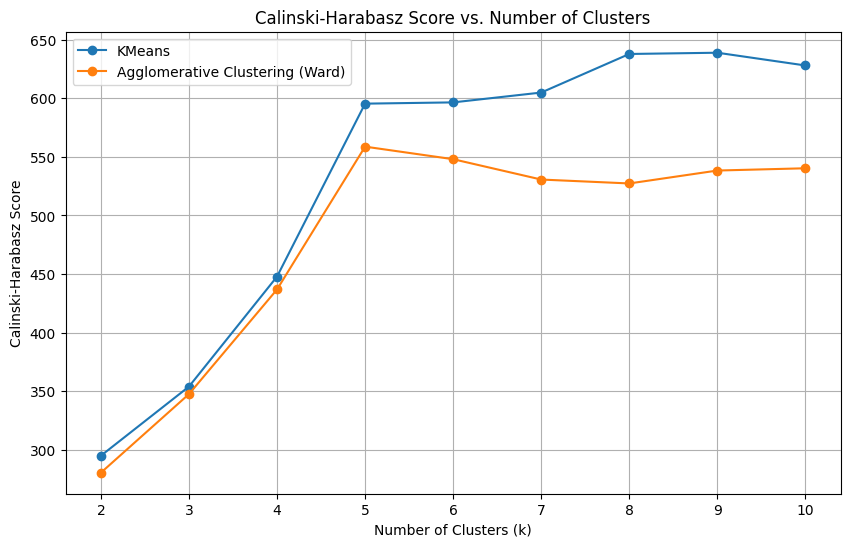

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot Calinski-Harabasz scores for KMeans
kmeans_ch_results = metrics_df_ch[(metrics_df_ch['model'] == 'KMeans') & (metrics_df_ch['n_clusters'] > 1)]
plt.plot(kmeans_ch_results['n_clusters'], kmeans_ch_results['calinski_harabasz'], marker='o', label='KMeans')

# Plot Calinski-Harabasz scores for Agglomerative Clustering
agg_ch_results = metrics_df_ch[(metrics_df_ch['model'] == 'Agglomerative') & (metrics_df_ch['n_clusters'] > 1)]
plt.plot(agg_ch_results['n_clusters'], agg_ch_results['calinski_harabasz'], marker='o', label='Agglomerative Clustering (Ward)')

plt.title('Calinski-Harabasz Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(range(2, 11)) # Assuming k ranges from 2 to 10
plt.grid(True)
plt.legend()
plt.show()

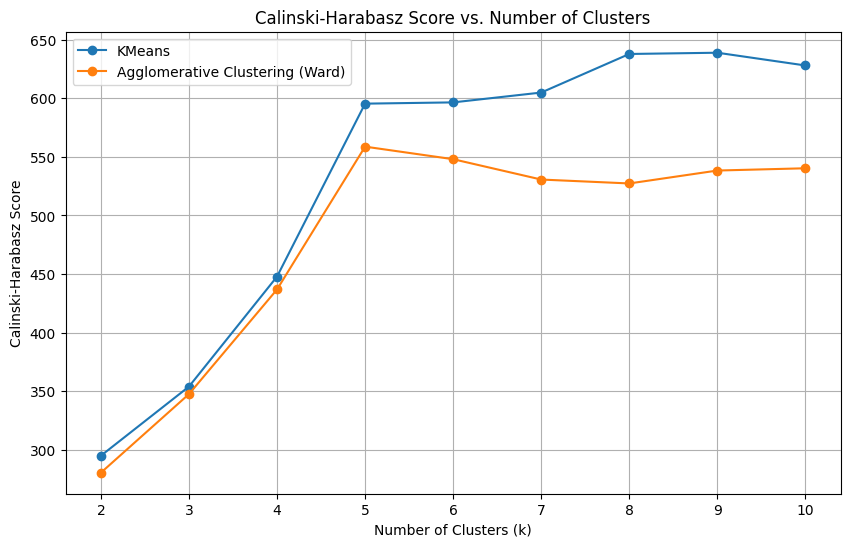

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plot Calinski-Harabasz scores for KMeans
kmeans_ch_results = metrics_df_ch[(metrics_df_ch['model'] == 'KMeans') & (metrics_df_ch['n_clusters'] > 1)]
plt.plot(kmeans_ch_results['n_clusters'], kmeans_ch_results['calinski_harabasz'], marker='o', label='KMeans')

# Plot Calinski-Harabasz scores for Agglomerative Clustering
agg_ch_results = metrics_df_ch[(metrics_df_ch['model'] == 'Agglomerative') & (metrics_df_ch['n_clusters'] > 1)]
plt.plot(agg_ch_results['n_clusters'], agg_ch_results['calinski_harabasz'], marker='o', label='Agglomerative Clustering (Ward)')

plt.title('Calinski-Harabasz Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Calinski-Harabasz Score')
plt.xticks(range(2, 11)) # Assuming k ranges from 2 to 10
plt.grid(True)
plt.legend()
plt.show()